# 6CS012 – Worksheet 4
## Fully Connected Network (FCN) for Devnagari Handwritten Digit Classification

**Tasks covered:** Data Preparation · Model Architecture · Compilation · Training · Evaluation · Save/Load · Predictions

---
## Task 1 – Data Preparation

In [ ]:
from google.colab import files
import zipfile
import os

if not os.path.exists("dataset"):
    os.makedirs("dataset")

print("Please upload your zipped dataset folder (e.g., dataset.zip):")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f"User uploaded file \"{fn}\"")
    if fn.endswith(".zip"):
        with zipfile.ZipFile(fn, 'r') as zip_ref:
            zip_ref.extractall("dataset/")
        print(f"Successfully extracted {fn} to 'dataset/'")
        os.remove(fn)
    else:
        print(f"Skipping non-zip file: {fn}")

print("Dataset upload and extraction complete.")

Please upload your zipped dataset folder (e.g., dataset.zip):


Saving Copy of devnagari digit.zip to Copy of devnagari digit.zip
User uploaded file "Copy of devnagari digit.zip"
Successfully extracted Copy of devnagari digit.zip to 'dataset/'
Dataset upload and extraction complete.


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

TRAIN_DIR = "/content/dataset/DevanagariHandwrittenDigitDataset/Train"
TEST_DIR  = "/content/dataset/DevanagariHandwrittenDigitDataset/Test"

IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    """
    Walks the class sub-folders inside `folder`, loads every image as a
    28×28 grayscale array normalised to [0, 1], and returns:
        images  – ndarray of shape (N, 28, 28)
        labels  – integer ndarray of shape (N,)
    """
    images, labels = [], []

    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}
    print(f"Classes found in '{folder}': {class_names}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.LANCZOS)
                img = np.array(img, dtype=np.float32) / 255.0
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"  Skipping {img_path}: {e}")

    return np.array(images), np.array(labels, dtype=np.int32)


x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)
x_test_raw,  y_test_raw  = load_images_from_folder(TEST_DIR)

print(f"\nRaw train shape : {x_train_raw.shape}, labels: {y_train_raw.shape}")
print(f"Raw test  shape : {x_test_raw.shape},  labels: {y_test_raw.shape}")

Classes found in '/content/dataset/DevanagariHandwrittenDigitDataset/Train': ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Classes found in '/content/dataset/DevanagariHandwrittenDigitDataset/Test': ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

Raw train shape : (17000, 28, 28), labels: (17000,)
Raw test  shape : (3000, 28, 28),  labels: (3000,)


In [ ]:

x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test  = x_test_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)

y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"x_train : {x_train.shape}   y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape}    y_test  : {y_test.shape}")

x_train : (17000, 784)   y_train : (17000, 10)
x_test  : (3000, 784)    y_test  : (3000, 10)


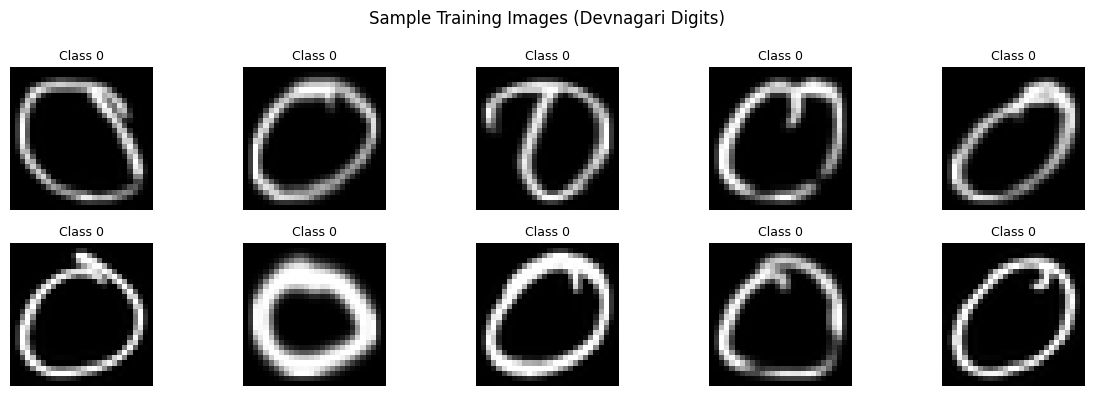

In [ ]:

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap="gray")
    plt.title(f"Class {np.argmax(y_train[i])}", fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Training Images (Devnagari Digits)", fontsize=12)
plt.tight_layout()
plt.show()

---
## Task 2 – Build the FCN Model

Architecture specified by the worksheet:
| Layer | Neurons | Activation |
|-------|---------|------------|
| Input (Flatten) | 784 | – |
| Hidden 1 | 64 | sigmoid |
| Hidden 2 | 128 | sigmoid |
| Hidden 3 | 256 | sigmoid |
| Output | 10 | softmax |

In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential(
    [
        Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),   # 784-dim input
        Dense(64,  activation="sigmoid", name="hidden_1"),
        Dense(128, activation="sigmoid", name="hidden_2"),
        Dense(256, activation="sigmoid", name="hidden_3"),
        Dense(NUM_CLASSES, activation="softmax", name="output"),
    ],
    name="FCN_Devnagari",
)

model.summary()

Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3 – Compile the Model

In [ ]:

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Model compiled.")

Model compiled.


---
## Task 4 – Train the Model

In [ ]:
BATCH_SIZE = 128
EPOCHS     = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_devnagari_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2702 - loss: 1.9201
Epoch 1: val_loss improved from None to 8.29263, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4500 - loss: 1.5739 - val_accuracy: 0.0000e+00 - val_loss: 8.2926
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8028 - loss: 0.6278
Epoch 2: val_loss did not improve from 8.29263
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8357 - loss: 0.5076 - val_accuracy: 0.0000e+00 - val_loss: 9.5782
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9045 - loss: 0.3192
Epoch 3: val_loss did not improve from 8.29263
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9157 - loss: 0.2894 - val_accuracy: 0.0000e+00 - val_loss: 10.1922
Epoch 4/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9387 - loss: 0.2171
Epoch 4: val_loss did not improve from 8.2

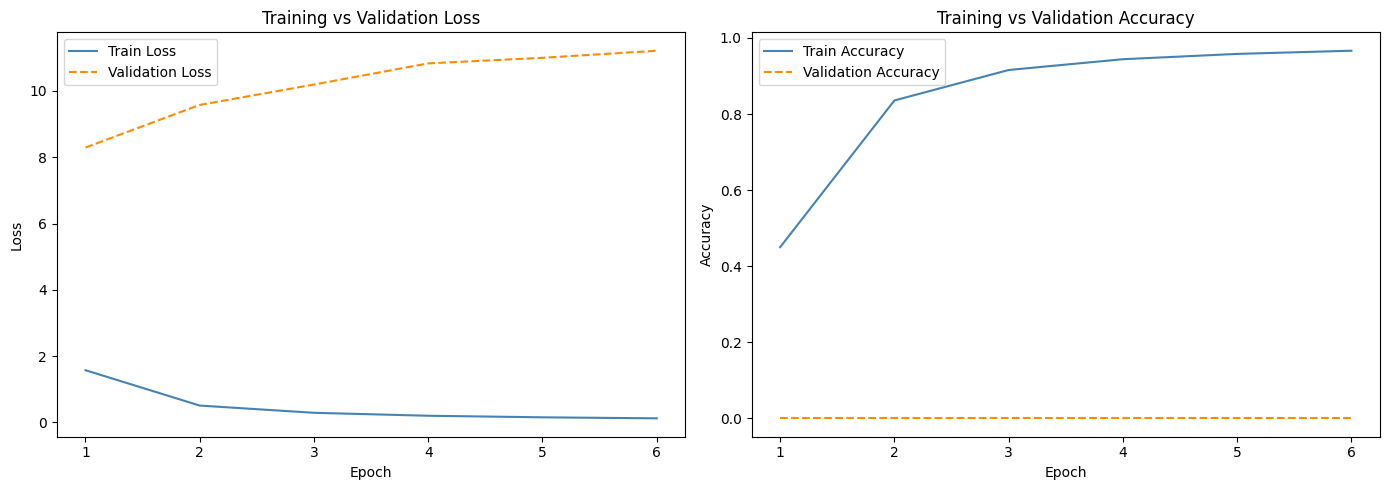

Training curves saved to training_curves.png


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs_range, history.history["loss"],     label="Train Loss",      color="steelblue")
axes[0].plot(epochs_range, history.history["val_loss"], label="Validation Loss", color="darkorange", linestyle="--")
axes[0].set_xlabel("Epoch");  axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()

axes[1].plot(epochs_range, history.history["accuracy"],     label="Train Accuracy",      color="steelblue")
axes[1].plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy", color="darkorange", linestyle="--")
axes[1].set_xlabel("Epoch");  axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Training curves saved to training_curves.png")

---
## Task 5 – Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n Test Loss     : {test_loss:.4f}")
print(f" Test Accuracy : {test_acc * 100:.2f} %")

94/94 - 0s - 2ms/step - accuracy: 0.6223 - loss: 2.2914

 Test Loss     : 2.2914
 Test Accuracy : 62.23 %


---
## Task 6 – Save and Load the Model

In [ ]:
SAVE_PATH = "devnagari_fcn_model.h5"
model.save(SAVE_PATH)
print(f"Model saved to '{SAVE_PATH}'")

Model saved to 'devnagari_fcn_model.h5'


In [ ]:
loaded_model = tf.keras.models.load_model(SAVE_PATH)
print(f"Model loaded from '{SAVE_PATH}'")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\n Loaded Model – Test Loss     : {loaded_loss:.4f}")
print(f" Loaded Model – Test Accuracy : {loaded_acc * 100:.2f} %")

Model loaded from 'devnagari_fcn_model.h5'
94/94 - 1s - 5ms/step - accuracy: 0.6223 - loss: 2.2914

 Loaded Model – Test Loss     : 2.2914
 Loaded Model – Test Accuracy : 62.23 %


---
## Task 7 – Making Predictions

In [ ]:
predictions      = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

print(f"Predicted label for first test image : {predicted_labels[0]}")
print(f"True label for first test image      : {true_labels[0]}")

Predicted label for first test image : 0
True label for first test image      : 0


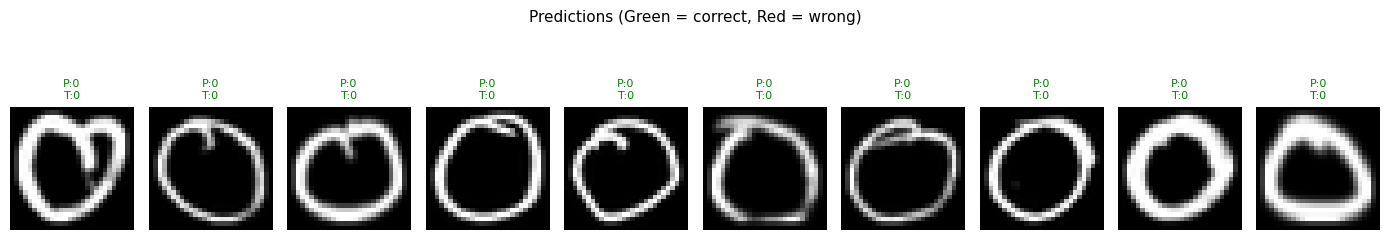

Prediction plot saved to predictions.png


In [ ]:
num_samples = 10
plt.figure(figsize=(14, 3))

for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test_raw[i], cmap="gray")

    pred  = predicted_labels[i]
    truth = true_labels[i]
    colour = "green" if pred == truth else "red"

    plt.title(f"P:{pred}\nT:{truth}", fontsize=8, color=colour)
    plt.axis("off")

plt.suptitle("Predictions (Green = correct, Red = wrong)", fontsize=11)
plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()
print("Prediction plot saved to predictions.png")

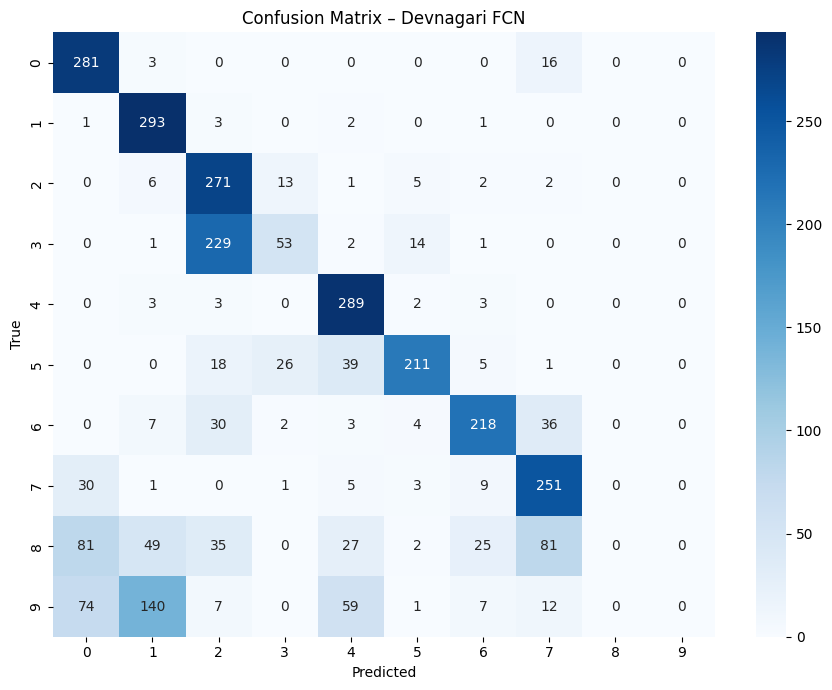


Per-class Report:
              precision    recall  f1-score   support

     Digit 0       0.60      0.94      0.73       300
     Digit 1       0.58      0.98      0.73       300
     Digit 2       0.45      0.90      0.60       300
     Digit 3       0.56      0.18      0.27       300
     Digit 4       0.68      0.96      0.80       300
     Digit 5       0.87      0.70      0.78       300
     Digit 6       0.80      0.73      0.76       300
     Digit 7       0.63      0.84      0.72       300
     Digit 8       0.00      0.00      0.00       300
     Digit 9       0.00      0.00      0.00       300

    accuracy                           0.62      3000
   macro avg       0.52      0.62      0.54      3000
weighted avg       0.52      0.62      0.54      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(NUM_CLASSES),
            yticklabels=range(NUM_CLASSES))
plt.xlabel("Predicted");  plt.ylabel("True")
plt.title("Confusion Matrix – Devnagari FCN")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nPer-class Report:")
print(classification_report(true_labels, predicted_labels,
                             target_names=[f"Digit {i}" for i in range(NUM_CLASSES)]))